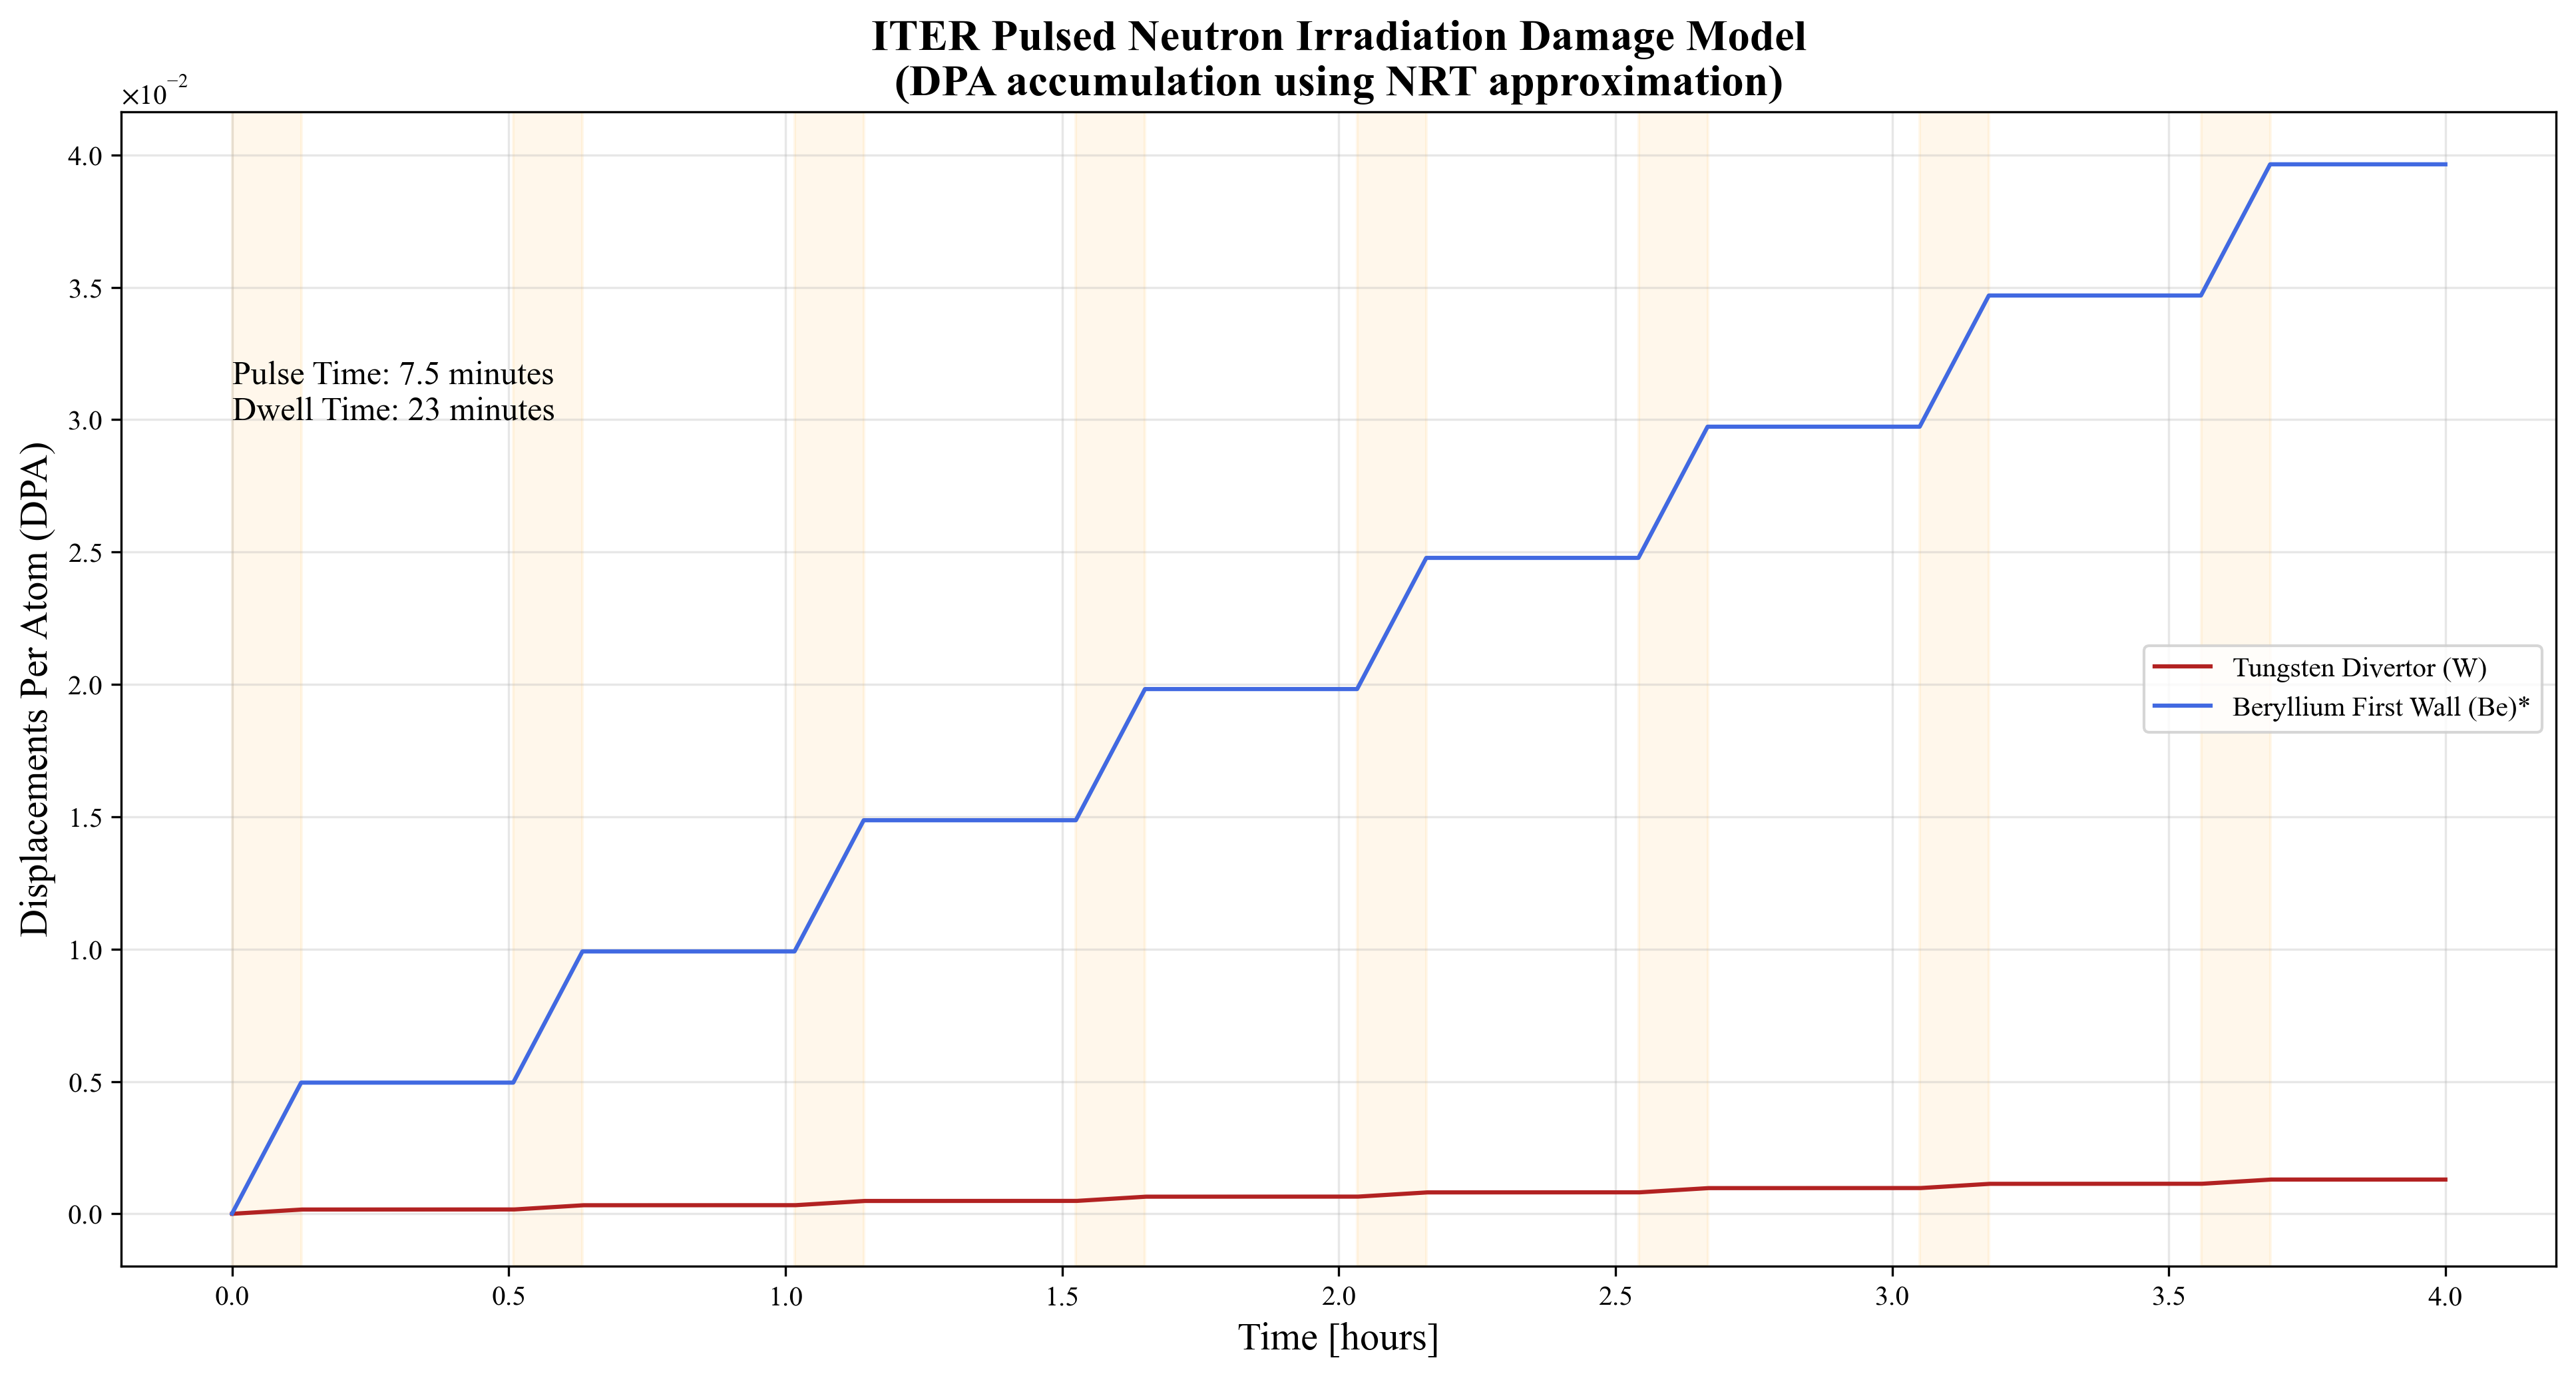

In [4]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import ScalarFormatter

# =========================================================
# FONT SETTINGS
# =========================================================
plt.rcParams["font.family"] = "Times New Roman"
plt.rcParams["mathtext.fontset"] = "stix"

# =========================================================
# CONSTANTS
# =========================================================
amu = 1.66053906660e-27          # [kg]
N_a = 6.02214076e23              # [atoms/mol]

# =========================================================
# TIME SETUP
# =========================================================
total_time = 4 * 3600            # [s]
dt = 1                          # [s]

time = np.arange(0, total_time, dt)
time_steps = len(time)

# =========================================================
# ITER PULSE STRUCTURE
# =========================================================
pulse_time = 450                 # [s] = 7.5 min
dwell_time = 1380                # [s] = 23 min
cycle_time = pulse_time + dwell_time   # [s]

# =========================================================
# NEUTRON FLUX (PULSE MODE)
# =========================================================
flux_cm = 1e14                # [n/cm²/s]

# UNIT CONVERSION
# [Eq.1] 1 cm² = 1e-4 m²
flux = flux_cm * 1e4             # [n/m²/s]

phi = np.zeros(time_steps)       # [n/m²/s]

# [Eq.2] Pulsed flux definition:
# φ(t) = φ₀ during pulse, 0 during dwell

for i, t in enumerate(time):

    t_cycle = t % cycle_time     # [s]

    if t_cycle < pulse_time:
        phi[i] = flux            # [n/m²/s]
    else:
        phi[i] = 0.0

# =========================================================
# MATERIAL PROPERTIES
# =========================================================

# Tungsten (W)
A_W = 0.18384                    # [kg/mol]
rho_W = 19250                   # [kg/m³]

# [Eq.3] atomic mass per atom:
m_W = A_W / N_a                 # [kg/atom]

Ed_W = 90                       # [eV] displacement threshold

# Beryllium (Be)
A_Be = 0.009012182              # [kg/mol]
rho_Be = 1850                  # [kg/m³]

m_Be = A_Be / N_a              # [kg/atom]
Ed_Be = 25                     # [eV]

# =========================================================
# NEUTRON PROPERTIES
# =========================================================
m_n = 1.008665 * amu            # [kg]
E_n = 14.1e6 * 1.602e-19        # [J]

# =========================================================
# GEOMETRY
# =========================================================
W_area = 1e-4                   # [m²]
Be_area = 1e-4                  # [m²]

W_thickness = 0.02             # [m]
Be_thickness = 0.02            # [m]

# =========================================================
# NUMBER OF ATOMS
# =========================================================

# [Eq.4] N = (ρ V) / m_atom
W_atoms = (rho_W * W_thickness * W_area) / m_W
Be_atoms = (rho_Be * Be_thickness * Be_area) / m_Be

# units: [atoms]

# =========================================================
# ENERGY TRANSFER (ELASTIC COLLISION)
# =========================================================

# [Eq.5] maximum transferable energy fraction:
# T = (4 m_n m_t / (m_n + m_t)^2) * E_n

T_W = (4 * m_n * m_W / (m_n + m_W)**2) * E_n     # [J]
T_Be = (4 * m_n * m_Be / (m_n + m_Be)**2) * E_n  # [J]

# =========================================================
# NRT DAMAGE MODEL
# =========================================================

# [Eq.6] NRT approximation:
# D = 0.8 * T / (2 * Ed)

Ed_W_J = Ed_W * 1.602e-19       # [J]
Ed_Be_J = Ed_Be * 1.602e-19     # [J]

disp_W = 0.8 * T_W / (2 * Ed_W_J)   # [displacements/neutron]
disp_Be = 0.8 * T_Be / (2 * Ed_Be_J) # [displacements/neutron]

# empirical correction
kappa = 1/3
disp_W *= kappa
disp_Be *= kappa

# =========================================================
# STORAGE
# =========================================================
dpa_history = np.zeros((time_steps, 2))

total_disp_W = 0.0
total_disp_Be = 0.0

# =========================================================
# DAMAGE EVOLUTION
# =========================================================

# [Eq.7] neutron count per step:
# N_n = φ A Δt

# [Eq.8] damage per step:
# D_i = N_n × D_per_neutron

for i in range(time_steps):

    flux_i = phi[i]             # [n/m²/s]

    neutrons_W = flux_i * W_area * dt    # [n]
    neutrons_Be = flux_i * Be_area * dt   # [n]

    dpa_W = neutrons_W * disp_W          # [displacements]
    dpa_Be = neutrons_Be * disp_Be       # [displacements]

    # [Eq.9] cumulative damage:
    total_disp_W += dpa_W
    total_disp_Be += dpa_Be

    # [Eq.10] DPA definition:
    dpa_history[i, 0] = total_disp_W / W_atoms   # [DPA]
    dpa_history[i, 1] = total_disp_Be / Be_atoms # [DPA]

# =========================================================
# PLOTTING
# =========================================================
fig, ax = plt.subplots(figsize=(13, 7), dpi=300)

time_hours = time / 3600   # [h]

ax.plot(time_hours, dpa_history[:, 0],
        label="Tungsten Divertor (W)",
        color="firebrick")

ax.plot(time_hours, dpa_history[:, 1],
        label="Beryllium First Wall (Be)*",
        color="royalblue")

# =========================================================
# VISUALIZE PULSES
# =========================================================
num_cycles = int(total_time // cycle_time)

for i in range(num_cycles + 1):

    start = i * cycle_time / 3600     # [h]
    end = (i * cycle_time + pulse_time) / 3600  # [h]

    ax.axvspan(start, end, color="orange", alpha=0.08)

# =========================================================
# LABELS
# =========================================================
ax.set_xlabel("Time [hours]", fontsize=14)
ax.set_ylabel("Displacements Per Atom (DPA)", fontsize=14)

ax.set_title(
    "ITER Pulsed Neutron Irradiation Damage Model\n"
    "(DPA accumulation using NRT approximation)",
    fontsize=16,
    fontweight="bold"
)

ax.text(
    x=.0, y=.03,
    s="Pulse Time: 7.5 minutes\nDwell Time: 23 minutes",
    fontsize=12
)

formatter = ScalarFormatter(useMathText=True)
formatter.set_powerlimits((0, 0))
ax.yaxis.set_major_formatter(formatter)

ax.legend()
ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()